In [1]:
#The first preprocessing steps are the same as in the Binary file.
#This file was used to get the accuracies of both the logistic regression and neural net for both binary cases

In [2]:
#Data read out and defining the variables:
import scipy.io
data = scipy.io.loadmat('210921.mat')

spks = data['spks']
tc = data['tc']
cue = data['cueAng']
cueIdx = data['cueAngIdx']
corr = data['isCorr']

#Here I selected the correct trials only and .flatten was needed since the dimension need to match.
corr = corr.flatten()
cueIdx = cueIdx.flatten()
corr_bool = corr == 1

#Only keeping the correct trials:
spks = spks[corr_bool]
cueIdx = cueIdx[corr_bool]


In [3]:
#Here the cue selection is done.
#Opposite cue pairs were (1, 5), (2, 6), (3, 7), and (4, 8).
#Neighbouring cue pairs were (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), and (8, 1)

import numpy as np
target_cue = 4
opp_cue = 8

#Obtaining a new dataset with only the right cues:
#The reason that the variables are named _48 is because I first tested the pipeline with the pair (4, 8)
in48 = np.isin(cueIdx, [target_cue, opp_cue])
spks_48 = spks[in48]
cue_48 = cueIdx[in48]

#This is the correct label array:
y = (cue_48 == target_cue).astype(int) 
y_labels = y

In [4]:
#Here the boxcar smoothing and downsampling are done.

n_trials, n_time, n_neurons = spks_48.shape
window_ms = 100 #For the smoothing 100ms
sample_step = 10 #For downsampling 10ms

#Defining the kernel:
boxcar_kernel = np.ones(window_ms, dtype=float) / window_ms

#List to input the smooth data to:
spks_smooth_full = np.zeros((n_trials, n_time, n_neurons), dtype=float)

#Looping over trials and neurons and then convolving over time to get a smooth representation.
for trial in range(n_trials):
    for neuron in range(n_neurons):
        spks_smooth_full[trial, :, neuron] = np.convolve(spks_48[trial, :, neuron],boxcar_kernel,mode='same')

# Sample every 10 ms
spks_smooth = spks_smooth_full[:, ::sample_step, :]

In [5]:
#Calculate z-score.
#List to store the scores:
z_score = np.zeros_like(spks_smooth)

#Loop over each timepoint and then computing the z-score formula:
for t in range(spks_smooth.shape[1]):
    mean = spks_smooth[:, t, :].mean(axis=0)
    std = spks_smooth[:, t, :].std(axis=0)
    z_score[:, t, :] = (spks_smooth[:, t, :] - mean) / (std + 1e-10) #1e-10 was needed to avoid division by 0.




dt = 0.01  
time = -0.5 + np.arange(spks_smooth.shape[1]) * dt

In [6]:
#Here the PCA analysis is done.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#Selecting time period (this is the last preprocessing step).
period = (time >= 0.3) & (time <= 1.4)
X_period = z_score[:, period, :]
time_period = time[period]

n_trials, n_time, n_neurons = X_period.shape
X_flat = X_period.reshape(n_trials * n_time, n_neurons) #Reshape needed since it has to be 2D for the PCA from sk-learn

pca = PCA()
pca.fit(X_flat)

PCA()

In [7]:
#Importing all necessary functions for the neural net analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#I was supposed to work with a gpu, but unfortunately there were some technical problems, so I used my cpu.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [8]:
#Here the structure of the neural net is defined.
class Decoder(nn.Module):

    def __init__(self):
        super(Decoder, self).__init__()

        self.fc1 = nn.Linear(10, 64)
        self.bn1 = nn.BatchNorm1d(64)
        
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        
        self.dropout = nn.Dropout(p=0.2)
        
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = F.sigmoid(x)

        return x

In [9]:
#Defining the variables for the neural net.
batch_size = 12
epochs = 50
learning_rate = 0.001
dropout_p = 0.2

#Lists to store accuracies:
nn_accuracy_list = np.zeros(n_time)
logreg_accuracy_list = np.zeros(n_time)

losses_by_time = {}

In [10]:
#Here the neural net is implented for each timepoint
for t in range(n_time):

    X_t = X_period[:, t, :]  

    X_train, X_test, y_train, y_test = train_test_split(X_t, y_labels, test_size=0.3, stratify=y_labels, random_state=0)
    pca = PCA(10) #10 PCA components
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    logreg = LogisticRegression(solver='liblinear')
    logreg.fit(X_train_pca, y_train)

    y_pred_logreg = logreg.predict(X_test_pca)
    logreg_accuracy_list[t] = accuracy_score(y_test, y_pred_logreg) #Logistic regression accuracies.

    #Going from numpy to the tensors:
    X_train_tensor = torch.from_numpy(X_train_pca).float()
    X_test_tensor = torch.from_numpy(X_test_pca).float().to(device)
    y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
    y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

    train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)


    model = Decoder()
    criterion = nn.BCELoss() #Binary cross entropy loss for binary classification.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) #Adam optimizer updates the network weights during training.
    losses = []

    
    for epoch in range(epochs):
        model.train() #Train mode
        running_loss = 0.0
        
        for x_batch, y_batch in train_loader:
            
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad() #Clear gradients from previous step
            preds = model(x_batch) #Forward pass
            loss = criterion(preds, y_batch) #This gives the loss from the prediction

            loss.backward() #Backpropagation
            optimizer.step() #Optimize
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

    losses_by_time[t] = losses #To see the losses 
    model.eval() #Evaluation mode

    #Disable gradient computation during testing.
    with torch.no_grad():
        probs = model(X_test_tensor) #Obtain probabilities
        y_pred_nn = (probs >= 0.5).float() #Above 0.5 since it is binary
        nn_accuracy = (y_pred_nn == y_test_tensor).float().mean().item() #Accuracy of neural net.

    nn_accuracy_list[t] = nn_accuracy

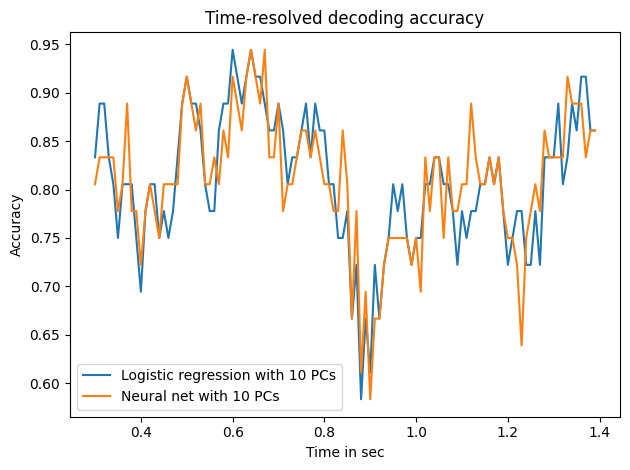

In [11]:
#Accuracy plots:
plt.plot(time_period, logreg_accuracy_list, label="Logistic regression with 10 PCs")

plt.plot(time_period, nn_accuracy_list, label="Neural net with 10 PCs")

plt.xlabel("Time in sec")
plt.ylabel("Accuracy")
plt.title("Time-resolved decoding accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
#Accuracies for one dataset:
print(f'Accuracy logistic regression: {np.mean(logreg_accuracy_list)}')
print(f'Accuracy neural net: {np.mean(nn_accuracy_list)}')

Accuracy logistic regression: 0.8095959595959598
Accuracy neural net: 0.8088383864272725
